# Power Simulation with PyBaMM

This notebook demonstrates how to perform constant power discharge simulation using PyBaMM with BYD Blade Prismatic 135Ah cell parameters.

## Overview
- **Cell**: BYD Blade Prismatic 135Ah LFP
- **Chemistry**: LFP (Lithium Iron Phosphate)
- **Form Factor**: Prismatic
- **Nominal Voltage**: 3.3V
- **Capacity**: 135Ah
- **Simulations**: Constant power discharge at multiple power levels

In [1]:
# Import required libraries
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from model_library import run_spmet

## 1. Load Cell Parameters

Load the cell design from the manifest file.

In [2]:
# Load cell manifest
manifest_path = Path("../cells/VW_ID3_Pouch_80Ah_manifest.json")
# manifest_path = Path("../cells/BYD_Blade_Prismatic_135Ah_manifest.json")

with open(manifest_path, 'r') as f:
    cell_design_manifest = json.load(f)

# ============================================================================
# POWER TEST CONFIGURATION
# ============================================================================
power_levels_W = [100, 200, 300, 400, 500, 750, 1000, 1250, 1500, 1750, 2000]
nominal_capacity = cell_design_manifest['kpis']['nominal_capacity']['value']
nominal_energy_Wh = cell_design_manifest["kpis"]["nominal_energy"]["value"] 

upper_voltage_cutoff = cell_design_manifest["cell_design"]["upper_voltage_cutoff"][
    "value"
]
lower_voltage_cutoff = cell_design_manifest["cell_design"]["lower_voltage_cutoff"][
    "value"
]

# Build experiment strings for each power level
experiments = []
labels = []
for power_W in power_levels_W:
    max_time_s = int(nominal_energy_Wh / power_W * 3600 * 1.2)  # 20% margin
    experiments.append(f"Discharge at {power_W}W for {max_time_s} seconds or until {lower_voltage_cutoff} V")
    labels.append(f"{power_W}W")

# Power test configuration dictionary
power_config = {
    "ambient_temperature": 298.15,  # 25°C
    "initial_temperature": 298.15,  # 25°C
    "initial_soc": 0.5,  # 50% SOC
    "c_rate": 1.0,  # 1C discharge
    "direction": "discharge",
    "duration_s": 30,
    "upper_voltage_cutoff": upper_voltage_cutoff,
    "lower_voltage_cutoff": lower_voltage_cutoff,
    "contact_resistance": 0.0001,
    "total_heat_transfer_coefficient": 10,
    "cooling_surface_area": 0.001,
    "experiments": experiments,
    "experiment_labels": labels,
}

## 2. Run Power Simulation

Run the SPMeT model with power experiment configuration at multiple power levels.

In [3]:
results = run_spmet(cell_design_manifest=cell_design_manifest, simulation_config=power_config)


Building model parameters from manifest...
  Positive electrode: sto_0=1.0056, sto_100=0.2448
  Negative electrode: sto_0=0.0539, sto_100=0.9959
  OCV at 0% cell SOC: 2.712 - 1.001 = 1.711 V
  OCV at 100% cell SOC: 4.344 - 0.009 = 4.335 V
  Parameters loaded

CAPACITY CALIBRATION
Target capacity: 80.50 Ah
Charge current: 26.83 A (C/3), Discharge current: 8.05 A (C/10)
Upper voltage: 4.2 V, Lower voltage: 2.8 V
Nominal capacity in params: 80.50 Ah
Pos sto limits: min=0.2448, max=1.0056
Neg sto limits: min=0.0539, max=0.9959
PyBaMM calculated cell capacity: 80.50 Ah
Experiment steps:
  1. Rest, Charge at 0.1C until 4.2 V, Hold at 4.2 V for 2 hours or until C/50
  2. Rest
  3. Discharge at 0.1C for 15 hours or until 2.8 V
  4. Rest
Convergence tolerance: 0.010%
--------------------------------------------------------------------------------
Iteration  1: Capacity =  70.74 Ah, Error = 12.118%
Iteration  2: Capacity =  82.20 Ah, Error =  2.112%
Iteration  3: Capacity =  80.26 Ah, Error =  

2026-01-19 06:57:14.033 - [WARNING] simulation.solve(942): Step 'Discharge at 2000W for 638 seconds or until 2.8 V' is infeasible at initial conditions, but skip_ok is True. Skipping step.


  Completed: 34 data points

Running: 2000W
  Experiment: Discharge at 2000W for 638 seconds or until 2.8 V
  Completed: 12 data points

Completed 11/11 experiments


## 3. Post-Processing: Calculate Power Metrics

Extract energy, duration, and other metrics from the raw time series data.

In [4]:
# Post-processing: Calculate power metrics from time series
successful_results = [r for r in results if r['success']]

power_metrics = []
for r in successful_results:
    time_s = r['time_s']
    voltage_V = r['voltage_V']
    energy_Wh = r['energy_Wh']
    temperature_K = r['temperature_K']
    
    # Calculate metrics
    discharge_energy_Wh = float(energy_Wh[-1] - energy_Wh[0])
    discharge_time_s = float(time_s[-1] - time_s[0])
    discharge_time_min = discharge_time_s / 60
    max_temperature_C = float(temperature_K.max() - 273.15)
    
    # Extract power from label
    power_W = int(r['experiment_label'].replace('W', ''))
    
    power_metrics.append({
        'power_W': power_W,
        'discharge_energy_Wh': discharge_energy_Wh,
        'discharge_time_min': discharge_time_min,
        'max_temperature_C': max_temperature_C,
        'time_s': time_s,
        'voltage_V': voltage_V,
        'temperature_K': temperature_K,
    })

# Display summary
if power_metrics:
    summary_data = [{
        'Power [W]': m['power_W'],
        'Energy [Wh]': f"{m['discharge_energy_Wh']:.2f}",
        'Duration [min]': f"{m['discharge_time_min']:.1f}",
        'Max Temp [C]': f"{m['max_temperature_C']:.1f}",
    } for m in power_metrics]
    
    summary_df = pd.DataFrame(summary_data)
    print("\nPower Simulation Results:")
    print(summary_df.to_string(index=False))


Power Simulation Results:
 Power [W] Energy [Wh] Duration [min] Max Temp [C]
       100       66.95           40.2         42.6
       200       43.89           13.2         44.3
       300       35.71            7.1         46.0
       400       28.41            4.3         46.1
       500        9.70            1.2         32.4
       750        6.00            0.5         30.6
      1000        5.04            0.3         30.6
      1250        4.62            0.2         31.0
      1500        3.54            0.1         30.2
      1750        1.07            0.0         26.7
      2000        0.00            0.0         25.0


## 4. Visualize Results

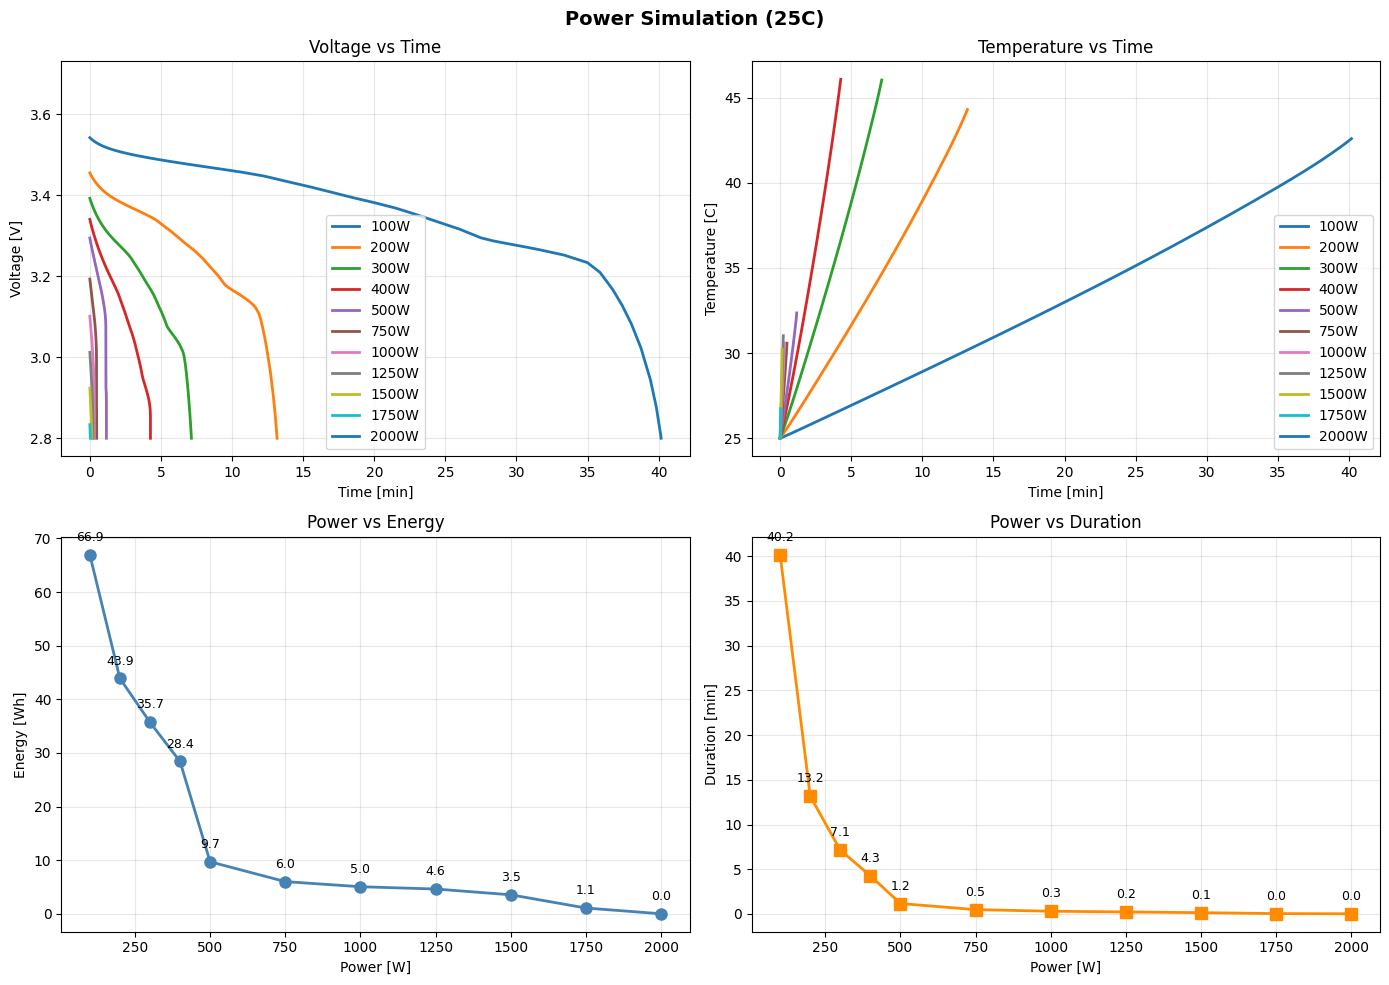

In [5]:
if len(power_metrics) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Plot 1: Voltage vs Time for all power levels
    ax1 = axes[0, 0]
    for m in power_metrics:
        time_min = (m['time_s'] - m['time_s'][0]) / 60
        ax1.plot(time_min, m['voltage_V'], linewidth=2, label=f"{m['power_W']}W")
    ax1.set_xlabel('Time [min]')
    ax1.set_ylabel('Voltage [V]')
    ax1.set_title('Voltage vs Time')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Temperature vs Time for all power levels
    ax2 = axes[0, 1]
    for m in power_metrics:
        time_min = (m['time_s'] - m['time_s'][0]) / 60
        temp_C = m['temperature_K'] - 273.15
        ax2.plot(time_min, temp_C, linewidth=2, label=f"{m['power_W']}W")
    ax2.set_xlabel('Time [min]')
    ax2.set_ylabel('Temperature [C]')
    ax2.set_title('Temperature vs Time')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Plot 3: Power vs Energy
    ax3 = axes[1, 0]
    power_levels_plot = [m['power_W'] for m in power_metrics]
    energies = [m['discharge_energy_Wh'] for m in power_metrics]
    ax3.plot(power_levels_plot, energies, 'o-', linewidth=2, markersize=8, color='steelblue')
    ax3.set_xlabel('Power [W]')
    ax3.set_ylabel('Energy [Wh]')
    ax3.set_title('Power vs Energy')
    ax3.grid(True, alpha=0.3)
    for p, e in zip(power_levels_plot, energies):
        ax3.annotate(f'{e:.1f}', (p, e), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)

    # Plot 4: Power vs Duration
    ax4 = axes[1, 1]
    durations = [m['discharge_time_min'] for m in power_metrics]
    ax4.plot(power_levels_plot, durations, 's-', linewidth=2, markersize=8, color='darkorange')
    ax4.set_xlabel('Power [W]')
    ax4.set_ylabel('Duration [min]')
    ax4.set_title('Power vs Duration')
    ax4.grid(True, alpha=0.3)
    for p, d in zip(power_levels_plot, durations):
        ax4.annotate(f'{d:.1f}', (p, d), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)

    plt.suptitle(f'Power Simulation ({power_config["ambient_temperature"]-273.15:.0f}C)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No successful simulations to plot.")